In [16]:
# Modules de base
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Module relatif à Gurobi
from gurobipy import *

# Get and process files

In [17]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import re
from typing import Any, Dict, List, Tuple, Optional, Union


# ----------------------------
# 1) File locator (decoupled)
# ----------------------------

def _format_density(density: Union[int, float, str]) -> str:
    if isinstance(density, str):
        s = density.strip()
        try:
            f = float(s)
            if f.is_integer():
                return str(int(f))
            return s.rstrip("0").rstrip(".") if "." in s else s
        except ValueError:
            return s
    if isinstance(density, (int, float)):
        f = float(density)
        if f.is_integer():
            return str(int(f))
        s = repr(f)
        return s.rstrip("0").rstrip(".")
    return str(density)


def find_dat_file(
    base_dir: Union[str, Path],
    density: Union[int, float, str],
    p: int,
    h: int,
    test: Optional[int] = None,
    *,
    top_folders: Tuple[str, str] = ("Data", "Data with maintenance constraints"),
    folder_prefix: str = "d=",
    file_prefix: str = "DataCplex_",
) -> Path:
    base_dir = Path(base_dir)
    d_str = _format_density(density)
    candidates: List[Path] = []
    for top in top_folders:
        d_folder = base_dir / top / f"{folder_prefix}{d_str}"
        if not d_folder.exists():
            continue
        if test is None:
            pattern = f"{file_prefix}density={d_str}_p={p}_h={h}_test_*.dat"
        else:
            pattern = f"{file_prefix}density={d_str}_p={p}_h={h}_test_{test}.dat"
        candidates.extend(sorted(d_folder.glob(pattern)))
    if not candidates:
        raise FileNotFoundError(
            f"No .dat file found for density={d_str}, p={p}, h={h}, test={test} under {base_dir}"
        )
    if len(candidates) > 1:
        msg = "\n".join(str(c) for c in candidates[:30])
        more = "" if len(candidates) <= 30 else f"\n... and {len(candidates)-30} more"
        raise FileExistsError(
            f"Multiple matching .dat files found for density={d_str}, p={p}, h={h}, test={test}:\n{msg}{more}\n"
            f"Pass test=<n> to select a unique file."
        )
    return candidates[0]


# ----------------------------
# 2) Parser (decoupled)
# ----------------------------

_DECL_RE = re.compile(r"(?ms)^\s*(\w+)\s*=\s*(.*?)\s*;\s*$")

def _parse_atom(token: str) -> Union[int, float, str]:
    token = token.strip()
    if token == "":
        return token
    try:
        if re.fullmatch(r"[+-]?\d+", token):
            return int(token)
        if re.fullmatch(r"[+-]?\d*\.\d+(?:[eE][+-]?\d+)?", token) or re.fullmatch(r"[+-]?\d+(?:[eE][+-]?\d+)", token):
            return float(token)
    except ValueError:
        pass
    return token


def _parse_set(value: str) -> List[Union[int, float, str]]:
    inner = value.strip()[1:-1].strip()
    if inner == "":
        return []
    parts = [p.strip() for p in inner.split(",")]
    parts = [p for p in parts if p != ""]
    return [_parse_atom(p) for p in parts]


def _parse_tuples_from_angle_brackets(value: str) -> List[Tuple[Union[int, float, str], ...]]:
    tuples: List[Tuple[Union[int, float, str], ...]] = []
    for body in re.findall(r"<([^<>]*)>", value, flags=re.S):
        fields = [f.strip() for f in body.split(",")]
        fields = [f for f in fields if f != ""]
        tuples.append(tuple(_parse_atom(f) for f in fields))
    return tuples


def _parse_matrix(value: str) -> List[List[Union[int, float]]]:
    s = value.strip()
    if not (s.startswith("[") and s.endswith("]")):
        raise ValueError("Matrix must start with '[' and end with ']'")
    content = s[1:-1].strip()
    rows: List[str] = []
    i = 0
    n = len(content)
    while i < n:
        while i < n and content[i].isspace():
            i += 1
        if i >= n:
            break
        if content[i] != "[":
            i += 1
            continue
        depth = 0
        start = i
        while i < n:
            ch = content[i]
            if ch == "[":
                depth += 1
            elif ch == "]":
                depth -= 1
                if depth == 0:
                    end = i
                    rows.append(content[start + 1 : end])
                    i += 1
                    break
            i += 1
    matrix: List[List[Union[int, float]]] = []
    for row in rows:
        nums = [x.strip() for x in row.replace("\n", " ").split(",")]
        nums = [x for x in nums if x != ""]
        parsed_row: List[Union[int, float]] = []
        for x in nums:
            atom = _parse_atom(x)
            if isinstance(atom, str):
                raise ValueError(f"Non-numeric value in matrix: {atom!r}")
            parsed_row.append(atom)
        matrix.append(parsed_row)
    return matrix


def parse_dat_file(dat_path: Union[str, Path]) -> Dict[str, Any]:
    dat_path = Path(dat_path)
    text = dat_path.read_text(encoding="utf-8", errors="replace")
    out: Dict[str, Any] = {}
    for m in _DECL_RE.finditer(text):
        name = m.group(1)
        raw = m.group(2).strip()
        if raw.startswith("{") and raw.endswith("}"):
            if "<" in raw and ">" in raw:
                out[name] = _parse_tuples_from_angle_brackets(raw)
            else:
                out[name] = _parse_set(raw)
        elif raw.startswith("[") and raw.endswith("]"):
            if "<" in raw and ">" in raw:
                out[name] = _parse_tuples_from_angle_brackets(raw)
            else:
                out[name] = _parse_matrix(raw)
        else:
            out[name] = _parse_atom(raw)
    return out


In [18]:
base = Path.cwd()

dat_file = find_dat_file(base, density=0.9, p=10, h=7, test=0)

data = parse_dat_file(dat_file)

print("Keys:", data.keys())
print("Nbflight:", data["Nbflight"])
print("First Flight tuple:", data["Flight"][0])
print("Cost shape:", len(data["Cost"]), "x", len(data["Cost"][0]) if data["Cost"] else 0)
print("First Aircraft tuple:", data["Aircraft"][0])

Airports   = data["Airports"]   # list of airport codes
Nbflight   = data["Nbflight"]   # number of flights
Aircrafts  = data["Aircrafts"]  # list of aircraft ids
Flight     = data["Flight"]     # list of tuples (flight_id, origin, destination, departure_time, arrival_time)
Cost       = data["Cost"]       # Cost[i][k] = cost of flight i (0-based) on aircraft k
Aircraft   = data["Aircraft"]   # list of tuples (aircraft_id, initial_airport)

# Flight_id starts on 1
# Aircraft_id starts on 0

Keys: dict_keys(['Airports', 'Nbflight', 'Aircrafts', 'Flight', 'Cost', 'Aircraft'])
Nbflight: 167
First Flight tuple: (1, 'MAD', 'HAM', 6360.0, 6615.0)
Cost shape: 167 x 10
First Aircraft tuple: (0, 'HAM')


# Modeling

## Pre-processing: build lookup dictionaries and feasibility structures

In [19]:
from gurobipy import Model, GRB, quicksum

MIN_TURN_TIME = 0  # minimum ground time between consecutive flights (minutes)

# flight_dict: flight_id (1-based) -> {org, dst, dep, arr}
flight_dict = {
    int(f[0]): {"org": f[1], "dst": f[2], "dep": f[3], "arr": f[4]}
    for f in Flight
}
all_flight_ids = list(flight_dict.keys())  # 1-based flight ids

# aircraft_dict: aircraft_id (0-based) -> initial_airport
aircraft_dict = {
    int(a[0]): a[1]
    for a in Aircraft
}
all_aircraft_ids = list(aircraft_dict.keys())  # 0-based aircraft ids

# feasible_arcs: list of (flight_i_id, flight_j_id) where j can follow i
#   C1 - turn time:   dep_j >= arr_i + MIN_TURN_TIME
#   C2 - continuity:  dst_i == org_j
feasible_arcs = []
for i_id in all_flight_ids:
    for j_id in all_flight_ids:
        if i_id == j_id:
            continue
        f_i = flight_dict[i_id]
        f_j = flight_dict[j_id]
        if f_i["dst"] != f_j["org"]:
            continue
        if f_j["dep"] < f_i["arr"] + MIN_TURN_TIME:
            continue
        feasible_arcs.append((i_id, j_id))

# valid_starts: list of (aircraft_id, flight_j_id) where aircraft can start with flight j
#   C3 - initial position: initial_airport_k == org_j
valid_starts = []
for k_id, start_pos in aircraft_dict.items():
    for j_id in all_flight_ids:
        if start_pos == flight_dict[j_id]["org"]:
            valid_starts.append((k_id, j_id))

# A[i_id][j_id] = True if flight j_id can follow flight i_id (for DFS)
feasible_arcs_set = set(feasible_arcs)

print(f"Generated {len(feasible_arcs)} feasible flight connections.")
print(f"Generated {len(valid_starts)} feasible start connections.")

Generated 1389 feasible flight connections.
Generated 221 feasible start connections.


# Modeling — column generation

## Helper functions

In [20]:
from gurobipy import Model, GRB, quicksum

MIN_TURN_TIME = 0  # minimum ground time between consecutive flights (minutes)

# ── Lookup dictionaries (same as xijt.ipynb) ─────────────────────────────────
# flight_dict: flight_id (1-based) -> {org, dst, dep, arr}
flight_dict = {
    int(f[0]): {"org": f[1], "dst": f[2], "dep": f[3], "arr": f[4]}
    for f in Flight
}
all_flight_ids = list(flight_dict.keys())  # 1-based

# aircraft_dict: aircraft_id (0-based) -> initial_airport
aircraft_dict = {
    int(a[0]): a[1]
    for a in Aircraft
}
all_aircraft_ids = list(aircraft_dict.keys())  # 0-based

# ── Feasibility structures (same as xijt.ipynb) ───────────────────────────────
# feasible_arcs: (i_id, j_id) where flight j can follow flight i
#   C1 - turn time:   dep_j >= arr_i + MIN_TURN_TIME
#   C2 - continuity:  dst_i == org_j
feasible_arcs = []
for i_id in all_flight_ids:
    for j_id in all_flight_ids:
        if i_id == j_id:
            continue
        f_i = flight_dict[i_id]
        f_j = flight_dict[j_id]
        if f_i["dst"] != f_j["org"]:
            continue
        if f_j["dep"] < f_i["arr"] + MIN_TURN_TIME:
            continue
        feasible_arcs.append((i_id, j_id))

# valid_starts: (aircraft_id, flight_j_id) where aircraft can open with flight j
#   C3 - initial position: initial_airport_k == org_j
valid_starts = []
for k_id, start_pos in aircraft_dict.items():
    for j_id in all_flight_ids:
        if start_pos == flight_dict[j_id]["org"]:
            valid_starts.append((k_id, j_id))

# adjacency list: next_flights[i_id] = list of j_id that can follow i_id
next_flights = {i_id: [] for i_id in all_flight_ids}
for (i_id, j_id) in feasible_arcs:
    next_flights[i_id].append(j_id)

print(f"Generated {len(feasible_arcs)} feasible flight connections.")
print(f"Generated {len(valid_starts)} feasible start connections.")


# ── Cost helpers ──────────────────────────────────────────────────────────────
def string_cost(flight_ids, k_id):
    """Total operating cost of a string for aircraft k.
    Cost[fid-1][k_id] follows the 1-based flight / 0-based aircraft convention.
    """
    return sum(Cost[fid - 1][k_id] for fid in flight_ids)


# ── Pricing subproblem ────────────────────────────────────────────────────────
def pricing_subproblem(k_id, pi, mu):
    """Find the string for aircraft k with the most negative reduced cost.

    The reduced cost of a string s = [f1, f2, ..., fn] on aircraft k is:
        rc(s, k) = string_cost(s, k) - sum_{i in s} pi[i] - mu[k]

    This is a shortest-path problem on the compatibility DAG:
        arc weight(i -> j) = Cost[j-1][k]  - pi[j]
        source arc  weight = Cost[j-1][k]  - pi[j]   for valid start flights j
    The path weight equals string_cost - sum(pi) for the flights in the path.
    We subtract mu[k] once at the end.

    Uses Bellman-Ford on the time-ordered DAG (no negative cycles possible
    because time is strictly increasing along any feasible arc).

    Returns (flight_ids, reduced_cost) if rc < 0, else (None, None).
    """
    start_pos = aircraft_dict[k_id]

    # dist[fid] = best (lowest) cumulative reduced-cost to reach fid
    # pred[fid] = predecessor flight id (None => came from source)
    INF = float("inf")
    dist = {fid: INF for fid in all_flight_ids}
    pred = {fid: None for fid in all_flight_ids}

    # Initialise from valid start flights for this aircraft
    for (ac, j_id) in valid_starts:
        if ac != k_id:
            continue
        w = Cost[j_id - 1][k_id] - pi[j_id]  # arc weight from source to j
        if w < dist[j_id]:
            dist[j_id] = w
            pred[j_id] = -1  # sentinel: came from source

    # Relax arcs in topological order (sorted by departure time of j)
    sorted_flights = sorted(all_flight_ids, key=lambda fid: flight_dict[fid]["dep"])
    for i_id in sorted_flights:
        if dist[i_id] == INF:
            continue
        for j_id in next_flights[i_id]:
            w = Cost[j_id - 1][k_id] - pi[j_id]  # arc weight i -> j
            new_dist = dist[i_id] + w
            if new_dist < dist[j_id]:
                dist[j_id] = new_dist
                pred[j_id] = i_id

    # Find best endpoint (minimum dist over all flights)
    best_fid = min(all_flight_ids, key=lambda fid: dist[fid])
    best_path_cost = dist[best_fid] - mu[k_id]  # subtract aircraft dual

    if best_path_cost >= -1e-6:  # no improving column
        return None, None

    # Reconstruct path by backtracking through pred
    path = []
    node = best_fid
    while node != -1 and node is not None:
        path.append(node)
        node = pred[node]
    path.reverse()

    return path, best_path_cost


Generated 1389 feasible flight connections.
Generated 221 feasible start connections.


## Step 1 — Build the restricted master problem (RMP)

Start with one trivial string per aircraft (its first valid flight only). The RMP is solved as an LP relaxation (continuous `y`) so we can extract dual variables.

In [21]:
# ── Initial columns: one single-flight string per aircraft ────────────────────
# all_strings_cg: list of (aircraft_id, [flight_id, ...])
# Mirrors the all_strings structure used in flight_string.ipynb.
all_strings_cg = []
for k_id, start_pos in aircraft_dict.items():
    for j_id in all_flight_ids:
        if flight_dict[j_id]["org"] == start_pos:
            all_strings_cg.append((k_id, [j_id]))
            break  # one seed string per aircraft is enough to start

# string_flights_cg[s_idx] = set of flight ids covered by string s_idx
string_flights_cg = [set(s[1]) for s in all_strings_cg]

print(f"Initial columns: {len(all_strings_cg)} strings (one seed per aircraft)")

# ── Big-M penalty for artificial variables ────────────────────────────────────
# Each coverage constraint gets an artificial variable a[i_id] >= 0 with a very
# large cost M. This guarantees the RMP is always feasible from the first iteration
# and gives meaningful dual values even when most flights are not yet covered by
# any real string. The LP drives artificials to 0 as improving columns are added.
BIG_M = max(Cost[i][k] for i in range(Nbflight) for k in range(len(Aircrafts))) * Nbflight

# ── Build the LP relaxation of the RMP ───────────────────────────────────────
rmp = Model("tail_assignment_cg_rmp")
rmp.params.OutputFlag = 0

# y_cg[(s_idx, k_id)] — CONTINUOUS in [0,1] for the LP relaxation
y_cg = {}
for s_idx, (k_id, flight_ids) in enumerate(all_strings_cg):
    c = string_cost(flight_ids, k_id)
    y_cg[s_idx, k_id] = rmp.addVar(
        lb=0.0, ub=1.0, obj=c,
        vtype=GRB.CONTINUOUS,
        name=f"y_{s_idx}_{k_id}"
    )

# a[i_id] — artificial variable for flight i's coverage constraint
# Cost BIG_M forces it to 0 as soon as a real column covers the flight.
a = {}
for i_id in all_flight_ids:
    a[i_id] = rmp.addVar(
        lb=0.0, ub=1.0, obj=BIG_M,
        vtype=GRB.CONTINUOUS,
        name=f"a_{i_id}"
    )

rmp.ModelSense = GRB.MINIMIZE
rmp.update()

# C1 - Flight coverage constraints (stored for dual extraction)
# sum_{strings covering i} y[s,k]  +  a[i]  == 1   for all flights i
cover_constrs = {}
for i_id in all_flight_ids:
    covering = quicksum(
        y_cg[s_idx, k_id]
        for s_idx, (k_id, flight_ids) in enumerate(all_strings_cg)
        if i_id in string_flights_cg[s_idx]
    )
    cover_constrs[i_id] = rmp.addConstr(
        covering + a[i_id] == 1, name=f"Cover_{i_id}"
    )

# C2 - Aircraft uniqueness constraints (stored for dual extraction)
unique_constrs = {}
for k_id in all_aircraft_ids:
    unique_constrs[k_id] = rmp.addConstr(
        quicksum(
            y_cg[s_idx, k_id]
            for s_idx, (ac_id, _) in enumerate(all_strings_cg)
            if ac_id == k_id
        ) <= 1,
        name=f"Unique_{k_id}"
    )

rmp.optimize()

if rmp.status == GRB.OPTIMAL:
    print(f"Initial RMP LP value: {rmp.objVal:.2f}")
    n_artificial = sum(1 for i_id in all_flight_ids if a[i_id].X > 1e-6)
    print(f"Flights still covered by artificial variables: {n_artificial}")
else:
    print(f"RMP status: {rmp.status} (unexpected — check data)")


Initial columns: 10 strings (one seed per aircraft)
Initial RMP LP value: 654898455.00
Flights still covered by artificial variables: 161


## Step 2 — Column generation loop

At each iteration: solve RMP → extract duals → run pricing subproblem for each aircraft → add improving columns → repeat until no column with negative reduced cost exists.

In [22]:
MAX_ITER = 500   # safety cap on iterations
TOL      = 1e-6  # reduced-cost threshold for optimality

cg_log = []  # (iteration, columns_added, rmp_obj, n_artificial)

for iteration in range(1, MAX_ITER + 1):

    # ── 1. Solve current RMP ──────────────────────────────────────────────────
    rmp.optimize()

    if rmp.status != GRB.OPTIMAL:
        print(f"RMP became infeasible or unbounded at iteration {iteration}, status={rmp.status}")
        break

    rmp_obj = rmp.objVal
    n_artificial = sum(1 for i_id in all_flight_ids if a[i_id].X > 1e-6)

    # ── 2. Extract dual variables ─────────────────────────────────────────────
    # pi[i_id]  = dual of Cover_{i_id}  (flight coverage constraint)
    # mu[k_id]  = dual of Unique_{k_id} (aircraft uniqueness constraint)
    pi = {i_id: cover_constrs[i_id].Pi  for i_id in all_flight_ids}
    mu = {k_id: unique_constrs[k_id].Pi for k_id in all_aircraft_ids}

    # ── 3. Pricing subproblem: search for improving columns ───────────────────
    columns_added = 0
    for k_id in all_aircraft_ids:
        flight_ids, rc = pricing_subproblem(k_id, pi, mu)

        if flight_ids is None:
            continue  # no improving string for this aircraft

        # ── 4. Add the new column to the RMP ─────────────────────────────────
        s_idx = len(all_strings_cg)
        all_strings_cg.append((k_id, flight_ids))
        string_flights_cg.append(set(flight_ids))

        c = string_cost(flight_ids, k_id)
        new_var = rmp.addVar(
            lb=0.0, ub=1.0, obj=c,
            vtype=GRB.CONTINUOUS,
            name=f"y_{s_idx}_{k_id}"
        )
        y_cg[s_idx, k_id] = new_var

        # Update existing constraints with the new variable
        # C1: coverage constraints for flights in this string
        for fid in flight_ids:
            rmp.chgCoeff(cover_constrs[fid], new_var, 1.0)

        # C2: uniqueness constraint for this aircraft
        rmp.chgCoeff(unique_constrs[k_id], new_var, 1.0)

        columns_added += 1

    cg_log.append((iteration, columns_added, rmp_obj, n_artificial))

    print(f"Iter {iteration:3d} | cols added: {columns_added:3d} | "
          f"artificials: {n_artificial:3d} | "
          f"RMP LP obj: {rmp_obj:,.2f} | total strings: {len(all_strings_cg)}")

    # ── 5. Termination check ──────────────────────────────────────────────────
    # Converged when: no new columns AND all artificials are zero
    if columns_added == 0 and n_artificial == 0:
        print(f"\nColumn generation converged after {iteration} iterations.")
        print(f"LP optimal value (no artificials): {rmp_obj:,.2f}")
        print(f"Total columns generated: {len(all_strings_cg)}")
        break
    elif columns_added == 0 and n_artificial > 0:
        print(f"\nWarning: no new columns found but {n_artificial} flights still covered "
              f"by artificials. The instance may be infeasible for the given initial airports.")
        break
else:
    print(f"Warning: reached MAX_ITER={MAX_ITER} without convergence.")


Iter   1 | cols added:  10 | artificials: 161 | RMP LP obj: 654,898,455.00 | total strings: 20
Iter   2 | cols added:  10 | artificials: 132 | RMP LP obj: 537,129,902.00 | total strings: 30
Iter   3 | cols added:  10 | artificials: 132 | RMP LP obj: 537,129,902.00 | total strings: 40
Iter   4 | cols added:  10 | artificials: 132 | RMP LP obj: 537,129,902.00 | total strings: 50
Iter   5 | cols added:  10 | artificials: 104 | RMP LP obj: 423,458,095.00 | total strings: 60
Iter   6 | cols added:  10 | artificials: 104 | RMP LP obj: 423,458,095.00 | total strings: 70
Iter   7 | cols added:  10 | artificials: 104 | RMP LP obj: 423,458,095.00 | total strings: 80
Iter   8 | cols added:  10 | artificials: 104 | RMP LP obj: 423,458,095.00 | total strings: 90
Iter   9 | cols added:  10 | artificials: 104 | RMP LP obj: 423,458,095.00 | total strings: 100
Iter  10 | cols added:  10 | artificials: 104 | RMP LP obj: 423,458,095.00 | total strings: 110
Iter  11 | cols added:  10 | artificials: 104 | 

## Column generation convergence

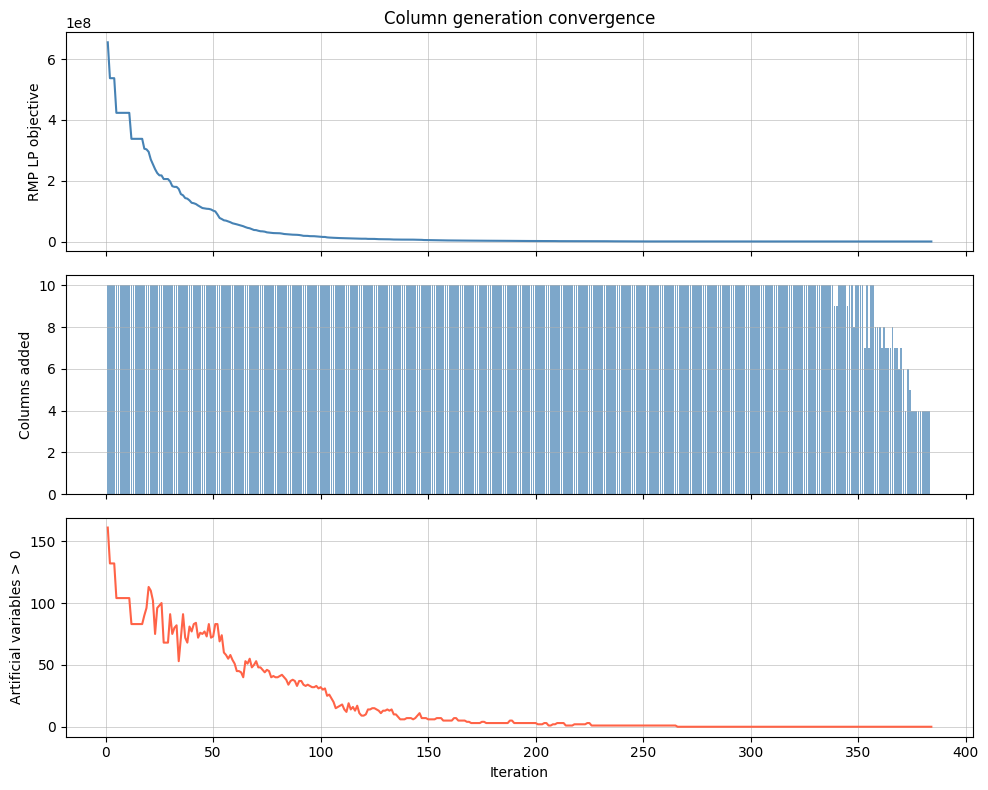

In [23]:
import matplotlib.pyplot as plt

iters        = [r[0] for r in cg_log]
obj_vals     = [r[2] for r in cg_log]
cols_added   = [r[1] for r in cg_log]
n_artificials = [r[3] for r in cg_log]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(iters, obj_vals, color="steelblue", linewidth=1.5)
ax1.set_ylabel("RMP LP objective")
ax1.set_title("Column generation convergence")
ax1.grid(True, linewidth=0.4)

ax2.bar(iters, cols_added, color="steelblue", alpha=0.7)
ax2.set_ylabel("Columns added")
ax2.grid(True, linewidth=0.4, axis="y")

ax3.plot(iters, n_artificials, color="tomato", linewidth=1.5)
ax3.set_ylabel("Artificial variables > 0")
ax3.set_xlabel("Iteration")
ax3.grid(True, linewidth=0.4)

plt.tight_layout()
plt.show()


## Step 3 — Re-solve as MIP over the generated columns

Once LP optimality is certified, fix `y` back to binary and re-solve. Because the LP relaxation is tight, branch-and-bound is typically very fast.

In [24]:
# ── Build MIP over the columns found by column generation ────────────────────
mip = Model("tail_assignment_cg_mip")
mip.params.OutputFlag = 0

# y[(s_idx, k_id)] — binary this time
y = {}  # reuse variable name 'y' consistent with flight_string.ipynb
for s_idx, (k_id, flight_ids) in enumerate(all_strings_cg):
    c = string_cost(flight_ids, k_id)
    y[s_idx, k_id] = mip.addVar(
        vtype=GRB.BINARY, obj=c,
        name=f"y_{s_idx}_{k_id}"
    )

mip.ModelSense = GRB.MINIMIZE
mip.update()

# C1 - Flight coverage
for i_id in all_flight_ids:
    mip.addConstr(
        quicksum(
            y[s_idx, k_id]
            for s_idx, (k_id, flight_ids) in enumerate(all_strings_cg)
            if i_id in string_flights_cg[s_idx]
        ) == 1,
        name=f"Cover_{i_id}"
    )

# C2 - Aircraft uniqueness
for k_id in all_aircraft_ids:
    mip.addConstr(
        quicksum(
            y[s_idx, k_id]
            for s_idx, (ac_id, _) in enumerate(all_strings_cg)
            if ac_id == k_id
        ) <= 1,
        name=f"Unique_{k_id}"
    )

mip.optimize()

if mip.status == GRB.OPTIMAL:
    print(f"MIP optimal value:      {mip.objVal:,.2f}")
    print(f"LP relaxation value:    {rmp.objVal:,.2f}")
    print(f"Integrality gap:        {(mip.objVal - rmp.objVal) / rmp.objVal * 100:.4f}%")
else:
    print(f"MIP: no optimal solution found, status = {mip.status}")

# Print assigned strings
for s_idx, (k_id, flight_ids) in enumerate(all_strings_cg):
    if y[s_idx, k_id].X > 0.5:
        route = " -> ".join(
            f"{flight_dict[fid]['org']}-{flight_dict[fid]['dst']}" for fid in flight_ids
        )
        print(f"Aircraft {k_id}: flights {flight_ids}  |  {route}")

MIP optimal value:      1,349,297.00
LP relaxation value:    1,349,297.00
Integrality gap:        0.0000%
Aircraft 3: flights [68, 94, 161, 162, 163, 164, 122, 147, 5, 6, 7, 8]  |  LGW-LUX -> LUX-LGW -> LGW-OSL -> OSL-FRA -> FRA-MXP -> MXP-FRA -> FRA-DUB -> DUB-HAM -> HAM-FRA -> FRA-HEW -> HEW-BCN -> BCN-MXP
Aircraft 9: flights [159, 160, 139, 138, 130, 131, 132, 146, 133, 134, 135, 136, 137, 143, 125, 145, 127, 126, 140, 141, 142]  |  MAD-BCN -> BCN-LGW -> LGW-HEW -> HEW-LGW -> LGW-MAN -> MAN-MXP -> MXP-NCE -> NCE-LGW -> LGW-MUC -> MUC-MRS -> MRS-MUC -> MUC-LGW -> LGW-MUC -> MUC-LGW -> LGW-GLA -> GLA-LGW -> LGW-GLA -> GLA-LGW -> LGW-FRA -> FRA-MXP -> MXP-LGW
Aircraft 7: flights [29, 30, 46, 47, 48, 43, 44, 45]  |  HAM-BCN -> BCN-HAM -> HAM-MRS -> MRS-MUC -> MUC-LGW -> LGW-FRA -> FRA-LGW -> LGW-MUC
Aircraft 4: flights [97, 52, 51, 62, 64, 65, 114, 63, 157, 158]  |  LGW-LUX -> LUX-LGW -> LGW-HAM -> HAM-OSL -> OSL-FRA -> FRA-LGW -> LGW-FRA -> FRA-HAM -> HAM-MRS -> MRS-MUC
Aircraft 1: fli

## Gantt chart

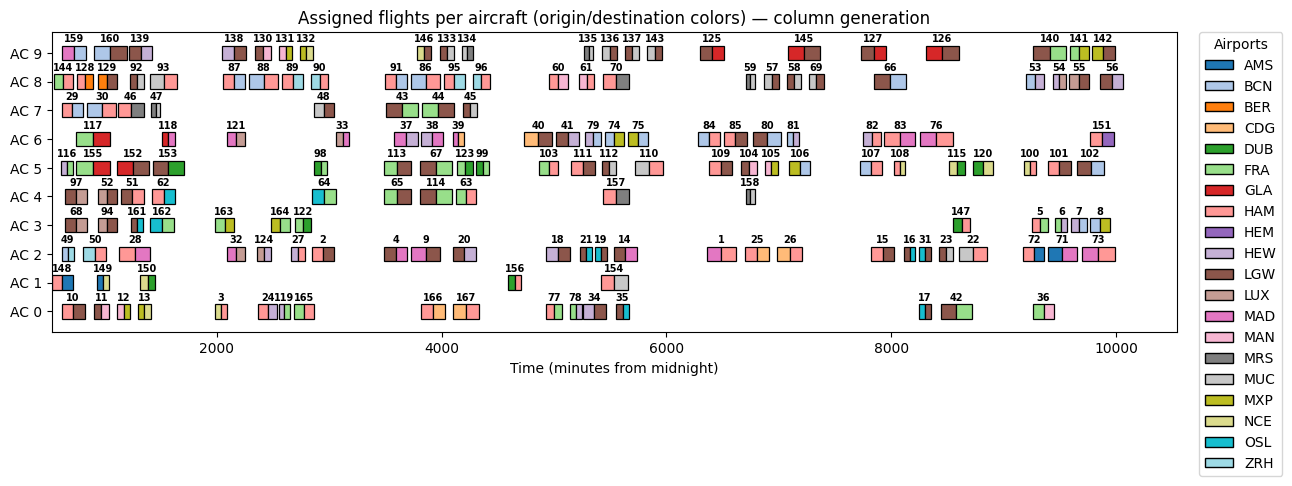

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --------- Build assigned flights from MIP string solution ----------
assigned = {k: [] for k in all_aircraft_ids}
airports = set()

for s_idx, (k_id, flight_ids) in enumerate(all_strings_cg):
    if y[s_idx, k_id].X > 0.5:
        for fid in flight_ids:
            f_info = flight_dict[fid]
            dep    = float(f_info["dep"])
            arr    = float(f_info["arr"])
            origin = f_info["org"]
            dest   = f_info["dst"]
            assigned[k_id].append((dep, arr, fid, origin, dest))
            airports.add(origin)
            airports.add(dest)

# sort flights per aircraft by departure time
for k in all_aircraft_ids:
    assigned[k].sort(key=lambda t: t[0])

# --------- Assign one color per airport ----------
airports = sorted(list(airports))
cmap = plt.get_cmap("tab20", len(airports))
airport_color = {ap: cmap(idx) for idx, ap in enumerate(airports)}

# --------- Plot ----------
row_spacing = 1.4
bar_height  = 0.7

used_aircraft = sum(1 for k in all_aircraft_ids if assigned[k])
fig, ax = plt.subplots(figsize=(13, max(2, 0.45 * used_aircraft)))

y_pos = 0
yticks = []
ylabels = []

for k_id in all_aircraft_ids:
    if not assigned[k_id]:
        continue

    yticks.append(y_pos)
    ylabels.append(f"AC {k_id}")

    for (dep, arr, fid, origin, dest) in assigned[k_id]:
        duration = arr - dep
        mid = dep + duration / 2.0

        # left half = origin color
        ax.barh(
            y_pos, mid - dep, left=dep, height=bar_height,
            color=airport_color[origin],
            edgecolor="black", linewidth=0.9
        )
        # right half = destination color
        ax.barh(
            y_pos, arr - mid, left=mid, height=bar_height,
            color=airport_color[dest],
            edgecolor="black", linewidth=0.9
        )
        # flight ID above the block
        ax.text(
            dep + duration / 2,
            y_pos + bar_height / 2 + 0.08,
            str(fid),
            ha="center", va="bottom",
            fontsize=7, fontweight="bold"
        )

    y_pos += row_spacing

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_xlabel("Time (minutes from midnight)")
ax.set_title("Assigned flights per aircraft (origin/destination colors) — column generation")

legend_elements = [
    Patch(facecolor=airport_color[ap], edgecolor='black', label=ap)
    for ap in airports
]
ax.legend(
    handles=legend_elements,
    title="Airports",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()